# Getting started: few-shot room segmentation on floor plans

This notebook shows how to find **every room** in a floor plan when you only have a few example plans, each with **one** room marked.
Nothing is trained. SAM proposes thousands of candidate regions, and DINOv2 features of the examples decide which candidates are rooms.

What you will do:

1. Look at the example data shipped in `examples/`.
2. Build the segmenter from five reference plans.
3. Segment one plan and look inside the pipeline.
4. Evaluate the result against ground truth.
5. Run all example plans, change a setting, and see the command-line equivalent.
6. Prepare your own data.

Runtime: about one minute on a CUDA GPU, most of it loading the models.

## 0. Setup

Run these once from the repository root:

```bash
pip install -r requirements.txt          # install PyTorch for your CUDA version first
mkdir -p checkpoints
wget -P checkpoints https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth
```

The DINOv2 weights (`facebook/dinov2-base`) download from Hugging Face on first use.
A CUDA GPU is strongly recommended: the SAM ViT-H encoder is slow on a CPU, and the pipeline peaks at about 8 GB of GPU memory.
Set the `SAM_CHECKPOINT` environment variable if you keep the checkpoint somewhere else.

In [2]:
import os
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import torch

from fewshot_sam import (FewShotRoomSegmenter, SegmenterConfig, evaluate_image, list_images, load_image,
                         load_instances, load_references, overlay_evaluation, overlay_masks, summarize)

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', message='IProgress not found')
plt.rcParams['figure.dpi'] = 80

# SAM_CHECKPOINT = os.environ.get('SAM_CHECKPOINT', 'checkpoints/sam_vit_h_4b8939.pth')
SAM_CHECKPOINT = '/home/donaldtrump/haolan/gradio_ui_pers_sam/checkpoints/sam_vit_h_4b8939.pth'
assert os.path.exists(SAM_CHECKPOINT), 'SAM checkpoint not found: download it first (see above).'
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', torch.cuda.get_device_name(0) if DEVICE == 'cuda' else 'cpu')

device: NVIDIA GeForce RTX 4090


## 1. The example data

```
examples/
├── references/
│   ├── images/00.jpg … 04.jpg   five reference floor plans
│   └── masks/00.png … 04.png    one marked room per plan (white = room)
└── test/
    ├── images/27.jpg … 87.jpg   six floor plans to segment
    └── gt/27.png … 87.png       ground-truth rooms as a label map (0 = no room, k = room k)
```

All plans come from the [CubiCasa5K](https://github.com/CubiCasa/CubiCasa5k) dataset.
The six test plans were chosen because the pipeline segments them well, so they show it at its best.

The reference masks do not have to be precise. Here each one is a rectangle drawn inside a single room, and all five mark a bedroom (MH);
the rooms found later include kitchens, bathrooms and halls as well.
A complete room mask, such as the ones written by `extract_cubicasa_data.py`, works too.

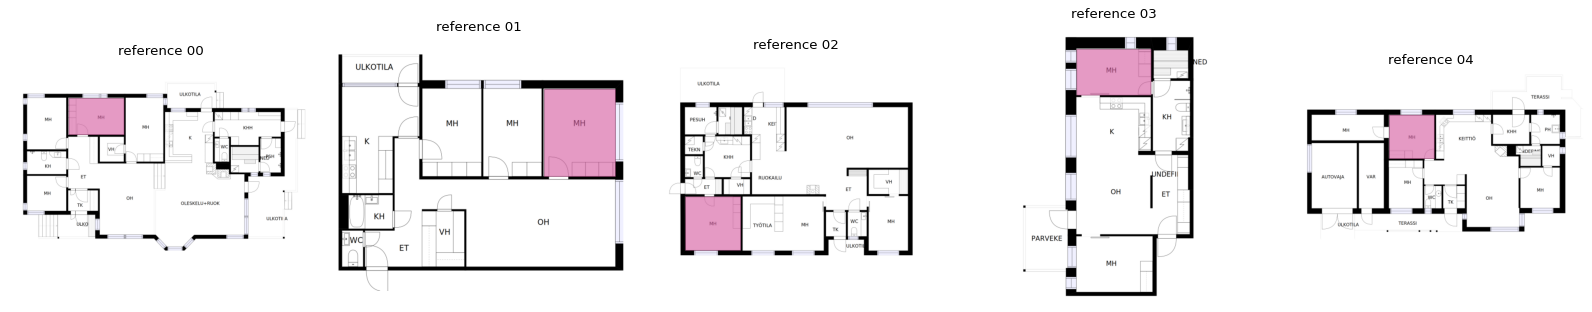

In [3]:
references = load_references('examples/references/images', 'examples/references/masks')

fig, axes = plt.subplots(1, len(references), figsize=(4 * len(references), 4))
for ax, (name, image, mask) in zip(axes, references):
    ax.imshow(overlay_masks(image, (mask > 0)[None], alpha=0.6, max_side=600))
    ax.set_title(f'reference {name}')
    ax.axis('off')
plt.tight_layout()
plt.show()

The plans carry Finnish room labels. The most common ones are MH (bedroom), OH (living room), K or KEITTIÖ (kitchen), ET (hall), KH (bathroom), WC (toilet), VH (walk-in closet), VAR (storage), KHH (utility room), and PARVEKE or TERASSI (balcony or terrace).

The ground truth follows one convention that matters for scoring. A room is a region enclosed by **walls or doors**:
open-plan areas joined through a doorless gap, such as a living room with an open kitchen, count as **one** room, while balconies and terraces are not rooms.

plan 87: 1092 x 1560 px, 10 ground-truth rooms


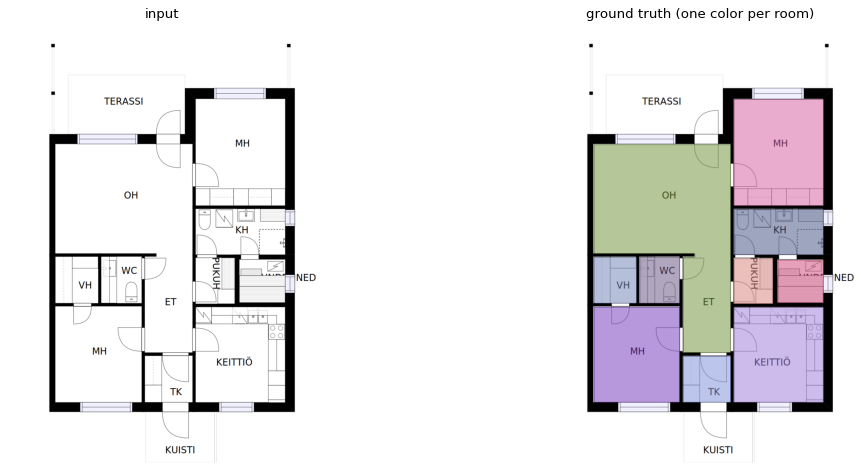

In [4]:
name = '87'
image = load_image(f'examples/test/images/{name}.jpg')
gt = load_instances(f'examples/test/gt/{name}.png')
print(f'plan {name}: {image.shape[1]} x {image.shape[0]} px, {len(gt)} ground-truth rooms')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(image)
axes[0].set_title('input')
axes[1].imshow(overlay_masks(image, gt, max_side=1000))
axes[1].set_title('ground truth (one color per room)')
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

## 2. Build the segmenter

`SegmenterConfig` holds every setting with its default value.
`FewShotRoomSegmenter` loads SAM ViT-H and DINOv2 once.
`set_references` encodes the reference plans with DINOv2, collects the features inside the marked rooms, and clusters them into a small **prototype bank** (three k-means centres by default).

In [7]:
config = SegmenterConfig(sam_checkpoint=SAM_CHECKPOINT, device=DEVICE)

t0 = time.time()
segmenter = FewShotRoomSegmenter(config)
prototypes = segmenter.set_references([(image_, mask_) for _, image_, mask_ in references])
print(f'models loaded and prototypes built in {time.time() - t0:.1f} s')
print('prototype bank shape:', tuple(prototypes.shape), '(prototypes x DINOv2 feature size)')

models loaded and prototypes built in 17.0 s
prototype bank shape: (3, 768) (prototypes x DINOv2 feature size)


## 3. Segment one plan and look inside

`segment(image)` returns a `(K, H, W)` boolean array, one mask per room.
With `return_details=True` it also returns what happened along the way:

* `similarity`: how much each location resembles the reference rooms, on SAM's 256 x 256 grid;
* `funnel`: how many candidates survive each step;
* `nms_masks_lowres`: the masks kept by the selection step, before the merge step and refinement.

11 rooms found in 2.83 s


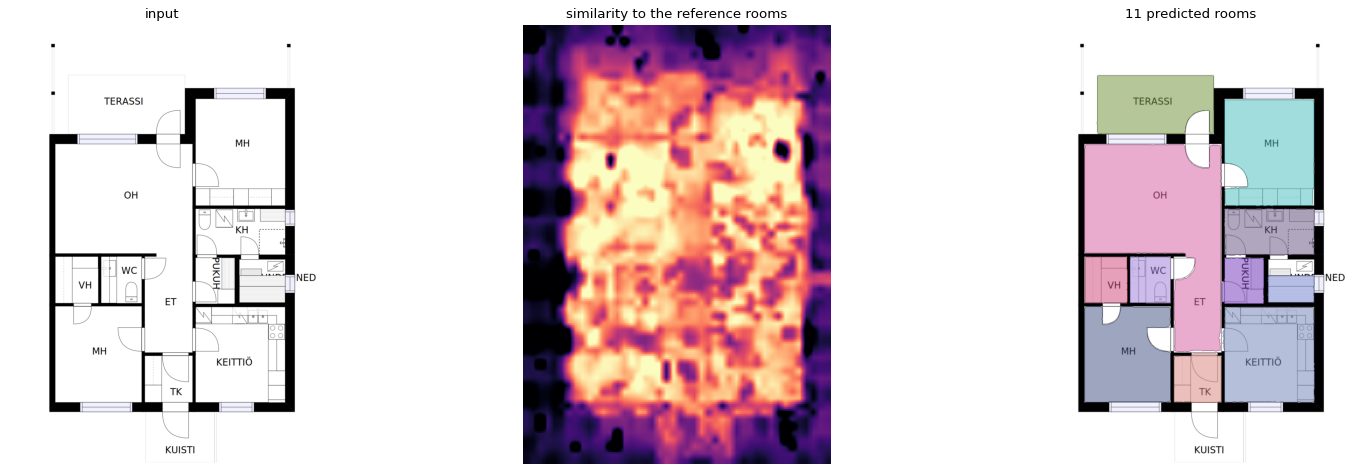

In [8]:
masks, details = segmenter.segment(image, return_details=True)
print(f"{len(masks)} rooms found in {details['seconds_total']:.2f} s")

H, W = image.shape[:2]
fig, axes = plt.subplots(1, 3, figsize=(21, 6))
axes[0].imshow(image)
axes[0].set_title('input')
axes[1].imshow(details['similarity'], cmap='magma', extent=(0, W, H, 0))
axes[1].set_title('similarity to the reference rooms')
axes[2].imshow(overlay_masks(image, masks, max_side=1000))
axes[2].set_title(f'{len(masks)} predicted rooms')
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

The similarity map alone cannot separate rooms: neighbouring rooms look alike, and walls between them are thin.
That is why the pipeline asks SAM for candidate regions first and uses the similarity only to *judge* them.

Every point of a 32 x 32 grid prompts SAM, and each prompt returns three candidate masks. The candidates then pass five checks:

| step | keeps a candidate when |
|---|---|
| similarity | the mean similarity inside it is at least 0.6 |
| ink | its interior is mostly blank (mean darkness at most 0.1); text and furniture symbols fail this |
| edge | for masks under 1 % of the plan: at least 40 % of its outline lies on drawn lines; labels and door arcs fail this |
| votes | at least 3 candidates, itself included, are near-duplicates of it (IoU of 0.7 or more); a real room is proposed by many grid points inside it |
| area | it covers between 0.05 % and 45 % of the plan |

The survivors are visited from most to least convincing. Overlapping masks and masks inside an already kept room are dropped, and thin pieces along a kept room are merged into it.
Finally, kept masks that touch along a long stretch without a drawn wall are merged, which joins open-plan areas and loose fragments such as counters, and each mask is refined with a box prompt.

candidates proposed by SAM                      2247
... similar enough to the references            1082
... with a blank interior                        718
... with an outline on drawn lines               577
... proposed at least 3 times                    565
... with a plausible size                        565
kept after overlap and containment checks         12
after merging masks joined without a wall         11
final rooms                                       11


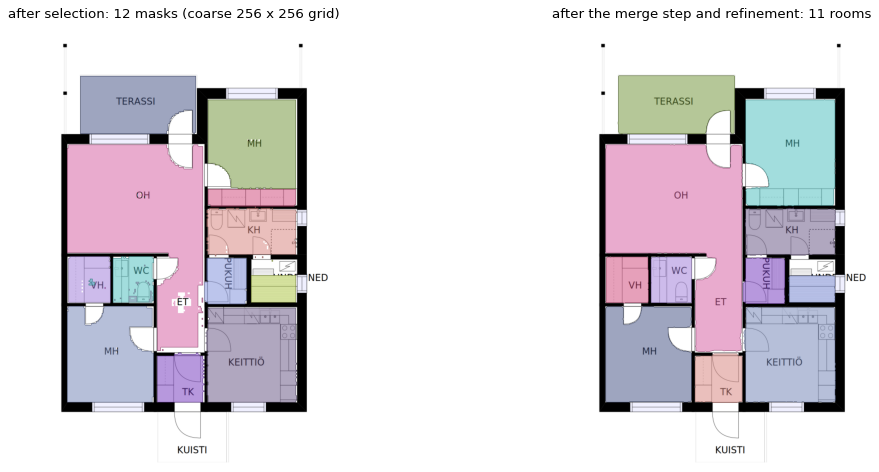

In [9]:
labels = {
    'candidates': 'candidates proposed by SAM',
    'similarity': '... similar enough to the references',
    'ink': '... with a blank interior',
    'edge': '... with an outline on drawn lines',
    'votes': '... proposed at least 3 times',
    'area': '... with a plausible size',
    'after_nms': 'kept after overlap and containment checks',
    'after_merge': 'after merging masks joined without a wall',
    'final': 'final rooms',
}
for key, label in labels.items():
    print(f'{label:<45} {details["funnel"][key]:>6}')

lowres = details['nms_masks_lowres']
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(overlay_masks(image, lowres, max_side=1000))
axes[0].set_title(f'after selection: {len(lowres)} masks (coarse 256 x 256 grid)')
axes[1].imshow(overlay_masks(image, masks, max_side=1000))
axes[1].set_title(f'after the merge step and refinement: {len(masks)} rooms')
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

## 4. Evaluate against ground truth

A predicted mask counts as a correct room when it overlaps a ground-truth room with an IoU of at least 0.5.
Pairs are matched one-to-one, best overlap first.
Unmatched predictions are false positives, and unmatched ground-truth rooms are false negatives.

rooms: 10 in ground truth, 11 predicted
matched 10, extra 1, missed 0
precision 0.909, recall 1.000, F1 0.952
mean IoU of matched rooms 0.920


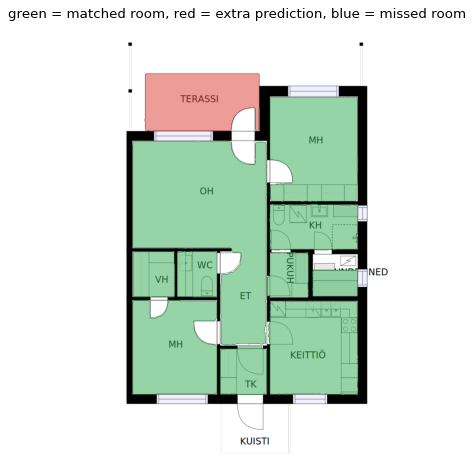

In [10]:
result = evaluate_image(masks, gt)
print(f"rooms: {result['n_gt']} in ground truth, {result['n_pred']} predicted")
print(f"matched {result['tp']}, extra {result['fp']}, missed {result['fn']}")
print(f"precision {result['precision']:.3f}, recall {result['recall']:.3f}, F1 {result['f1']:.3f}")
print(f"mean IoU of matched rooms {result['matched_iou']:.3f}")

plt.figure(figsize=(9, 7))
plt.imshow(overlay_evaluation(image, masks, gt, max_side=1000))
plt.title('green = matched room, red = extra prediction, blue = missed room')
plt.axis('off')
plt.show()

On this plan the corridor KÄYTÄVÄ comes back as a separate room (red).
The ground truth counts it as part of one open area together with the living room, kitchen and hall, which the large green mask matches at IoU 0.53.
The small room TK by the entrance is missed (blue).

## 5. Run all example plans

In [11]:
if DEVICE == 'cuda':
    torch.cuda.reset_peak_memory_stats()

rows, predictions = [], {}
for path in list_images('examples/test/images'):
    image_ = load_image(path)
    gt_ = load_instances(f'examples/test/gt/{path.stem}.png')
    t0 = time.time()
    predictions[path.stem] = segmenter.segment(image_)
    seconds = time.time() - t0
    rows.append(dict(image=path.stem, seconds=seconds, **evaluate_image(predictions[path.stem], gt_)))

print(f"{'plan':>5} {'rooms':>6} {'pred':>5} {'tp':>4} {'fp':>4} {'fn':>4} {'F1':>6} {'IoU':>6} {'time':>6}")
for r in rows:
    print(f"{r['image']:>5} {r['n_gt']:>6} {r['n_pred']:>5} {r['tp']:>4} {r['fp']:>4} {r['fn']:>4} "
          f"{r['f1']:6.3f} {r['matched_iou']:6.3f} {r['seconds']:5.1f}s")

s = summarize(rows)
print(f"\nall {s['images']} plans: precision {s['precision']:.3f}, recall {s['recall']:.3f}, F1 {s['f1']:.3f}")
if DEVICE == 'cuda':
    print(f'peak GPU memory: {torch.cuda.max_memory_allocated() / 1e9:.1f} GB')

 plan  rooms  pred   tp   fp   fn     F1    IoU   time
   27      8     8    8    0    0  1.000  0.867   2.2s
   32     11    12   11    1    0  0.957  0.861   2.7s
   35     15    15   14    1    1  0.933  0.891   3.2s
   46      8     8    8    0    0  1.000  0.944   2.0s
   68      7     7    7    0    0  1.000  0.913   1.7s
   87     10    11   10    1    0  0.952  0.920   2.1s

all 6 plans: precision 0.951, recall 0.983, F1 0.967
peak GPU memory: 7.7 GB


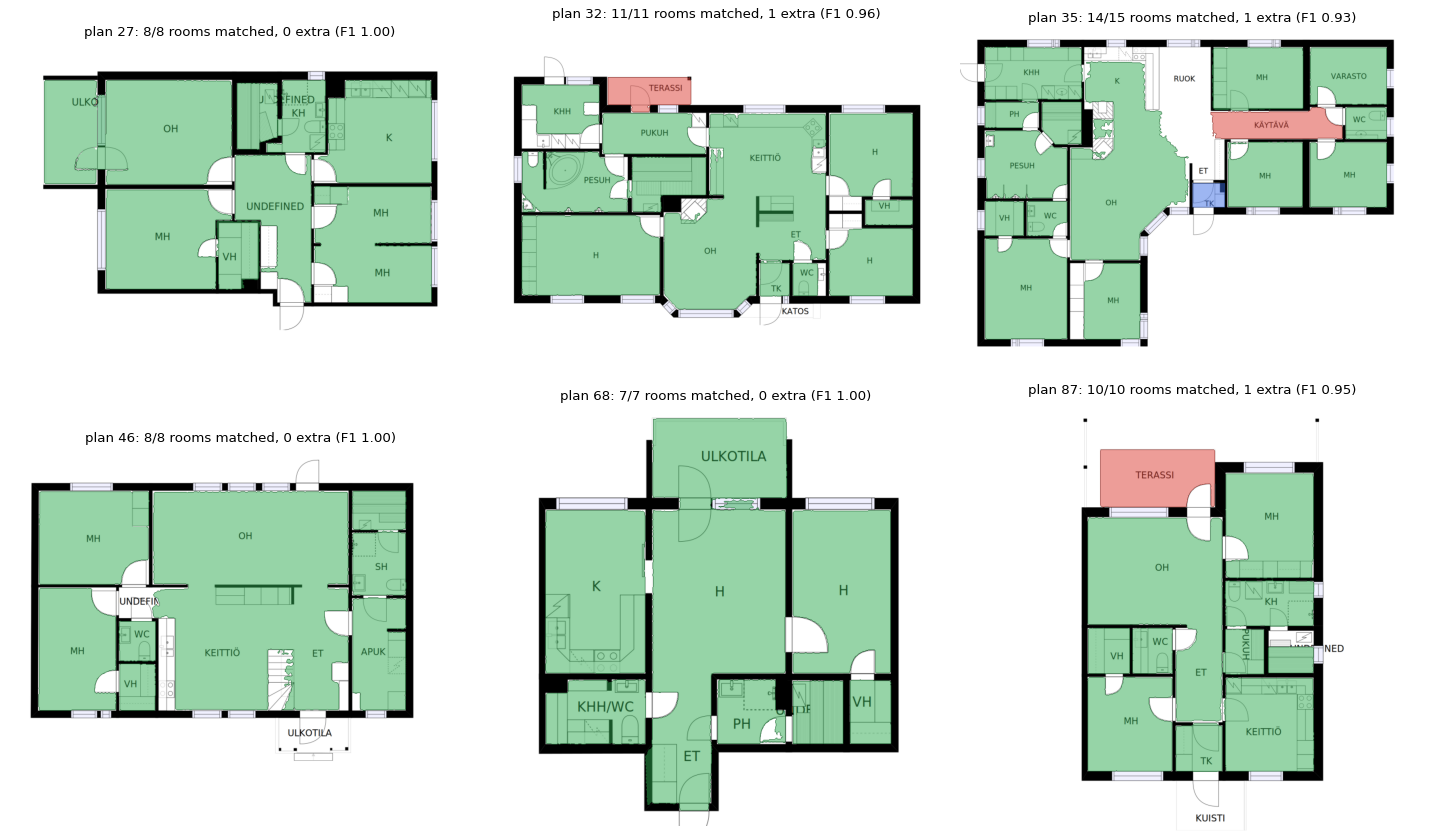

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
for ax, r in zip(axes.ravel(), rows):
    image_ = load_image(f"examples/test/images/{r['image']}.jpg")
    gt_ = load_instances(f"examples/test/gt/{r['image']}.png")
    ax.imshow(overlay_evaluation(image_, predictions[r['image']], gt_, max_side=900))
    ax.set_title(f"plan {r['image']}: {r['tp']}/{r['n_gt']} rooms matched, {r['fp']} extra (F1 {r['f1']:.2f})")
    ax.axis('off')
plt.tight_layout()
plt.show()

### Changing a setting

`update_config` changes settings without reloading the models (only the checkpoints, the device and the DINOv2 input size need a new segmenter).
As an example, switch off the merge step on plan 27. That step joins kept masks that touch along a long stretch without a drawn wall between them.

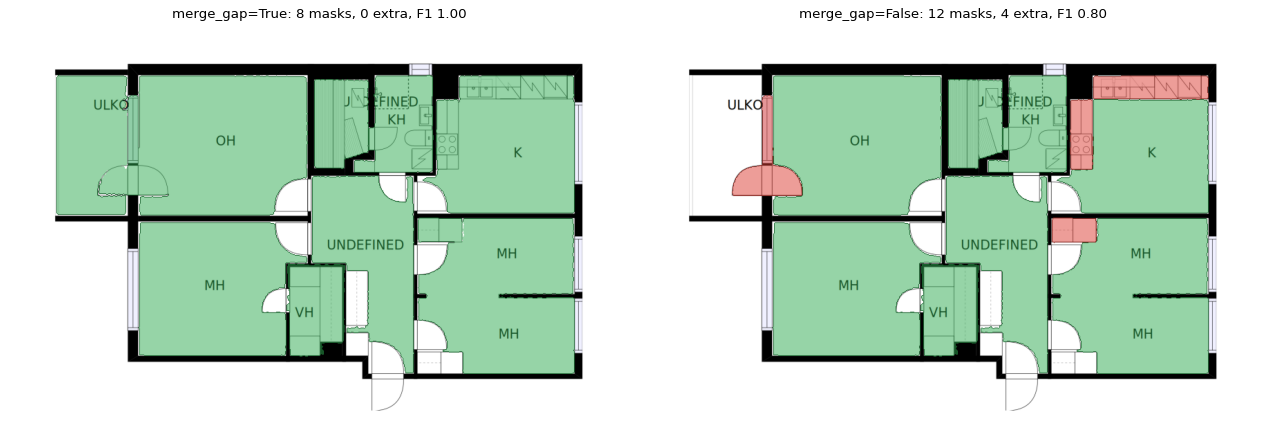

In [ ]:
name = '27'
image_ = load_image(f'examples/test/images/{name}.jpg')
gt_ = load_instances(f'examples/test/gt/{name}.png')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, merge in zip(axes, [True, False]):
    segmenter.update_config(merge_gap=merge)
    pred = segmenter.segment(image_)
    r = evaluate_image(pred, gt_)
    ax.imshow(overlay_evaluation(image_, pred, gt_, max_side=900))
    ax.set_title(f"merge_gap={merge}: {len(pred)} masks, {r['fp']} extra, F1 {r['f1']:.2f}")
    ax.axis('off')
plt.tight_layout()
plt.show()

_ = segmenter.update_config(merge_gap=True)  # back to the default

Without the merge, the kitchen counters, a wardrobe and part of the balcony come back as separate masks (red).
With it, each fragment is joined to the room it touches.
The merge also attaches the balcony to the living room here: that mask still matches at IoU 0.5, but its outline is too large.

The settings you are most likely to touch:

| setting | default | raise it to | lower it to |
|---|---|---|---|
| `min_similarity` | 0.6 | reject more non-rooms | recover rooms that look unlike the references |
| `max_ink` | 0.1 | keep rooms full of furniture symbols | reject more text and symbol regions |
| `min_votes` | 3 | reject more one-off fragments | recover very small rooms |
| `max_area_frac` | 0.45 | allow very large open-plan rooms | reject whole-apartment masks |
| `merge_gap` | True | | set False when every enclosed space must stay separate |
| `points_per_side` | 32 | propose more small rooms, slower | run faster |

The docstrings in `fewshot_sam/segmenter.py` describe every setting.

## 6. The same from the command line

`segment_floorplans.py` runs the pipeline over a folder and writes one `masks_<name>.npy` per plan; `evaluate.py` scores a folder of predictions.
Every field of `SegmenterConfig` is also a flag, for example `--min-similarity 0.5` or `--no-merge-gap`.

```bash
python segment_floorplans.py \
    --ref-images examples/references/images \
    --ref-masks examples/references/masks \
    --images examples/test/images \
    --output-dir outputs/examples \
    --save-vis

python evaluate.py --pred-dir outputs/examples --gt-dir examples/test/gt
```

## 7. Use your own floor plans

1. **Pick a few reference plans** drawn in the same style as the plans you want to segment, and mark one room in each. The examples use five.
2. **Save one mask per reference** as `<name>.png` next to the image `<name>.jpg`, white inside the room and black elsewhere. A rough box inside the room is enough. For CubiCasa5K, `extract_cubicasa_data.py --selected-mask-dir …` writes suitable masks.
3. **Run** `segment_floorplans.py` on a folder of plans, or call `segmenter.segment(image)` from Python.
4. **Evaluate** with `evaluate.py` if you have ground truth, either as label-map PNGs or as the `(num_rooms, H, W)` `.npy` files written by `extract_cubicasa_data.py`.

The checks in section 3 encode what a room looks like in a line drawing: a blank interior, bounded by walls.
Plans drawn in a very different style, such as filled or colored rooms, will likely need other `max_ink` and `min_edge_frac` values.